# Etap 3 - Deep learning: U-Net (PyTorch)

## 1. Przygotowanie środowiska

In [1]:
import sys, json, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src import io_utils, metrics, visualize, unet
from src.config import (
    TRAIN_IMAGES, TEST_IMAGES, RANDOM_SEED,
    MODELS_DIR, RESULTS_DIR,
)
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = unet.get_device()

## 2. Przygotowanie zbioru danych

Wewnętrzny podział train -> train_inner (33) / val_inner (6). `TEST_IMAGES` pozostają zarezerwowane do końcowej oceny. Z każdego obrazu losowe kropy 256×256 z augmentacją (rot90, flip) i samplingiem zbalansowanym na środki naczyń.

inner train: 33 obrazów
inner val:   6 obrazów = ['01_h', '02_h', '03_h', '04_h', '05_h', '06_h']
train_ds: 2112 kropów, val_ds: 96 kropów
sample shapes: x=(3, 256, 256), y=(1, 256, 256), fov=(1, 256, 256)


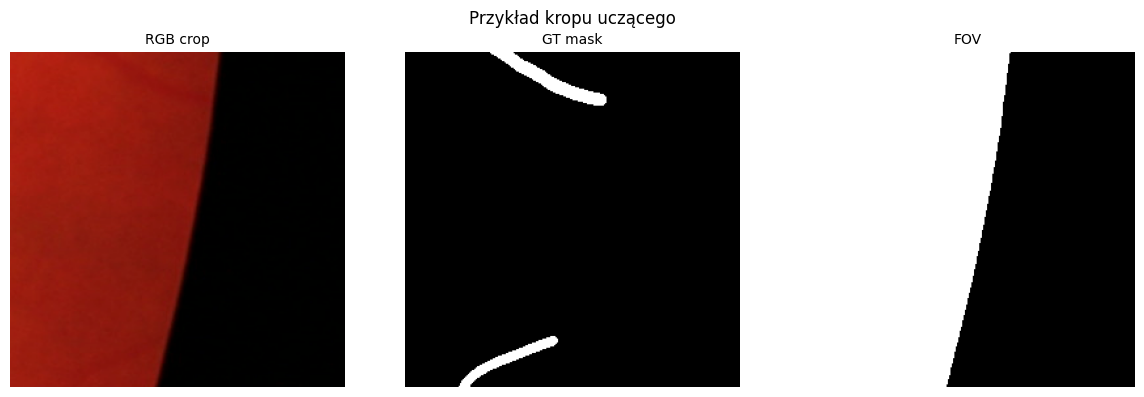

In [2]:
VAL_IMAGES_INNER = TRAIN_IMAGES[:6]
TRAIN_IMAGES_INNER = TRAIN_IMAGES[6:]
print(f'inner train: {len(TRAIN_IMAGES_INNER)} obrazów')
print(f'inner val:   {len(VAL_IMAGES_INNER)} obrazów = {VAL_IMAGES_INNER}')

CROP_SIZE = 256
CROPS_PER_TRAIN_IMAGE = 64
CROPS_PER_VAL_IMAGE   = 16

train_ds = unet.RetinaPatchDataset(
    TRAIN_IMAGES_INNER, loader=io_utils.load_triplet,
    crop_size=CROP_SIZE, crops_per_image=CROPS_PER_TRAIN_IMAGE,
    vessel_prob=0.5, seed=RANDOM_SEED,
)
val_ds = unet.RetinaPatchDataset(
    VAL_IMAGES_INNER, loader=io_utils.load_triplet,
    crop_size=CROP_SIZE, crops_per_image=CROPS_PER_VAL_IMAGE,
    vessel_prob=0.5, seed=RANDOM_SEED+1,
)
print(f'train_ds: {len(train_ds)} kropów, val_ds: {len(val_ds)} kropów')

# Wizualizacja jednego kropu dla sanity check.
x, y, fov = train_ds[0]
print(f'sample shapes: x={tuple(x.shape)}, y={tuple(y.shape)}, fov={tuple(fov.shape)}')
x_show = x.numpy().transpose(1, 2, 0)
x_show = (x_show * unet.RetinaPatchDataset.IMAGENET_STD + unet.RetinaPatchDataset.IMAGENET_MEAN)
x_show = np.clip(x_show, 0, 1)
fig = visualize.compare_grid([
    ('RGB crop', (x_show * 255).astype('uint8')),
    ('GT mask',  (y.squeeze().numpy() * 255).astype('uint8')),
    ('FOV',      (fov.squeeze().numpy() * 255).astype('uint8')),
], ncols=3, suptitle='Przykład kropu uczącego')
plt.show()

## 3. DataLoader i model

In [3]:
BATCH_SIZE = 8
NUM_WORKERS = 0  # na macOS lepiej 0, żeby uniknąć problemów z fork

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),
)

model = unet.UNet(in_channels=3, out_channels=1, encoder='resnet34').to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'U-Net (resnet34 backbone): {n_params/1e6:.2f}M parametrów')
print(model)

U-Net (resnet34 backbone): 24.44M parametrów
Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fal

## 4. Uczenie

Adam(lr=1e-3) + ReduceLROnPlateau, loss = BCE + Dice (oba maskowane przez FOV). Najlepszy checkpoint po G-mean zapisywany do `models/unet.pt`.

In [4]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / 'unet.pt'

EPOCHS = 30
LR = 1e-3

t0 = time.time()
history = unet.train(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device,
    save_best_to=model_path, progress=True,
)
print(f'\nUczenie zajęło {(time.time()-t0)/60:.1f} min')

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/Volumes/MACFILES/university/Informatyka w 
Medycynie/DnoOka/venv/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/Volumes/MACFILES/university/Informatyka w 
Medycynie/DnoOka/venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Volumes/MACFILES/university/Informatyka w 
Medycynie/DnoOka/venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

...

epoch  28: train_loss=0.3159  val_loss=0.2799  val_gmean=0.8955

epoch  29: train_loss=0.3199  val_loss=0.2563  val_gmean=0.8931

epoch  30: train_loss=0.3209  val_loss=0.2701  val_gmean=0.8924

`Trainer.fit` stopped: `max_epochs=30` reached.



Uczenie zajęło 52.2 min


### 4.1 Wykres uczenia

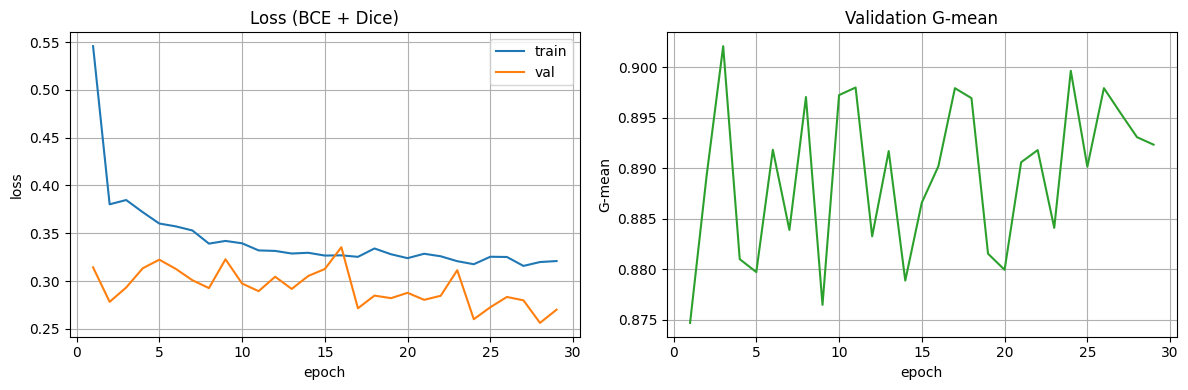

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history.train_loss) + 1)
ax[0].plot(ep, history.train_loss, label='train')
ax[0].plot(ep, history.val_loss,   label='val')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].legend(); ax[0].grid(True)
ax[0].set_title('Loss (BCE + Dice)')
ax[1].plot(ep, history.val_gmean, color='tab:green')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('G-mean'); ax[1].grid(True)
ax[1].set_title('Validation G-mean')
fig.tight_layout(); plt.show()

## 5. Predykcja na obrazach testowych

Najlepszy checkpoint + tiling 256 z overlapem 32 na tych samych `TEST_IMAGES`.

In [6]:
# load_model sam przenosi na device i przełącza w eval - gotowy do predict.
best_model = unet.load_model(
    model_path, in_channels=3, out_channels=1, encoder='resnet34', device=device,
)

per_image = {}
predictions = {}
for image_id in TEST_IMAGES:
    img, gt, fv = io_utils.load_triplet(image_id)
    t0 = time.time()
    pred = unet.predict_mask(
        best_model, img, fv, device=device,
        tile_size=256, overlap=32, threshold=0.5,
    )
    m = metrics.compute_metrics(pred, gt, fv)
    per_image[image_id] = m
    predictions[image_id] = (img, gt, fv, pred)
    print(f'{image_id}: {time.time()-t0:5.1f}s  '
          f'acc={m["accuracy"]:.4f}  sens={m["sensitivity"]:.4f}  '
          f'spec={m["specificity"]:.4f}  g_mean={m["g_mean"]:.4f}')

agg = metrics.aggregate(list(per_image.values()))
print('\n=== Statystyka zbiorcza (mean ± std) ===')
for k in ['accuracy', 'sensitivity', 'specificity', 'g_mean', 'balanced_accuracy']:
    print(f'  {k:20s} = {agg[k+"_mean"]:.4f} ± {agg[k+"_std"]:.4f}')

/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result e

14_h:   3.8s  acc=0.9692  sens=0.8488  spec=0.9830  g_mean=0.9134


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result e

15_h:   2.6s  acc=0.9760  sens=0.8229  spec=0.9916  g_mean=0.9033


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result e

...

15_dr:   2.7s  acc=0.9591  sens=0.8339  spec=0.9696  g_mean=0.8992


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result e

14_g:   2.6s  acc=0.9587  sens=0.7869  spec=0.9744  g_mean=0.8756


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result e

15_g:   2.6s  acc=0.9568  sens=0.8216  spec=0.9697  g_mean=0.8926

=== Statystyka zbiorcza (mean ± std) ===
  accuracy             = 0.9629 ± 0.0078
  sensitivity          = 0.8165 ± 0.0256
  specificity          = 0.9772 ± 0.0086
  g_mean               = 0.8932 ± 0.0154
  balanced_accuracy    = 0.8969 ± 0.0145


### 5.1 Porównanie wizualne

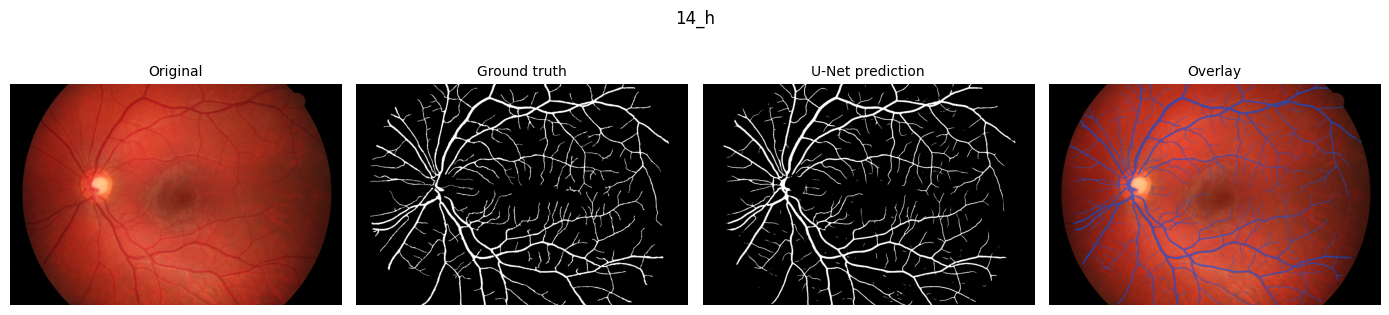

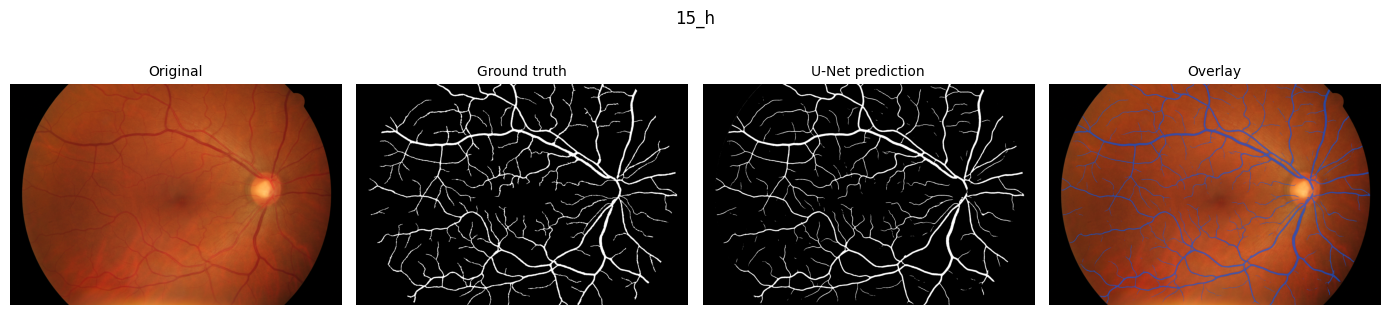

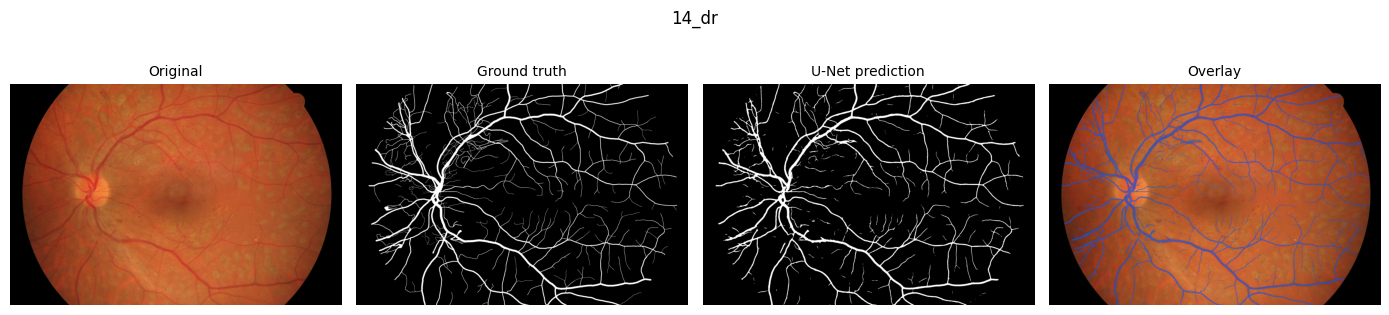

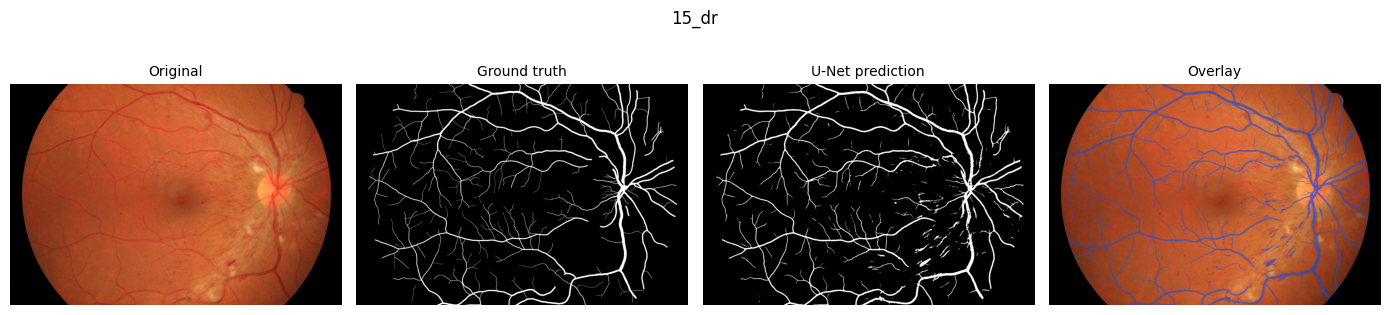

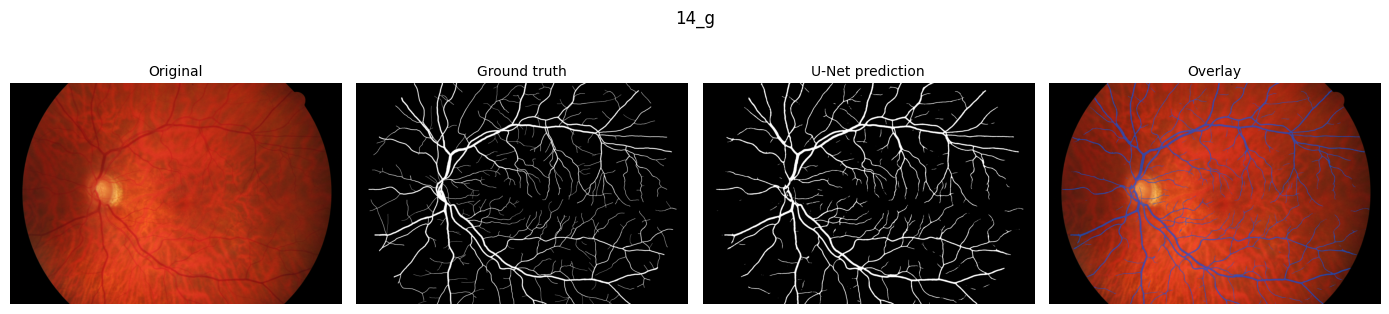

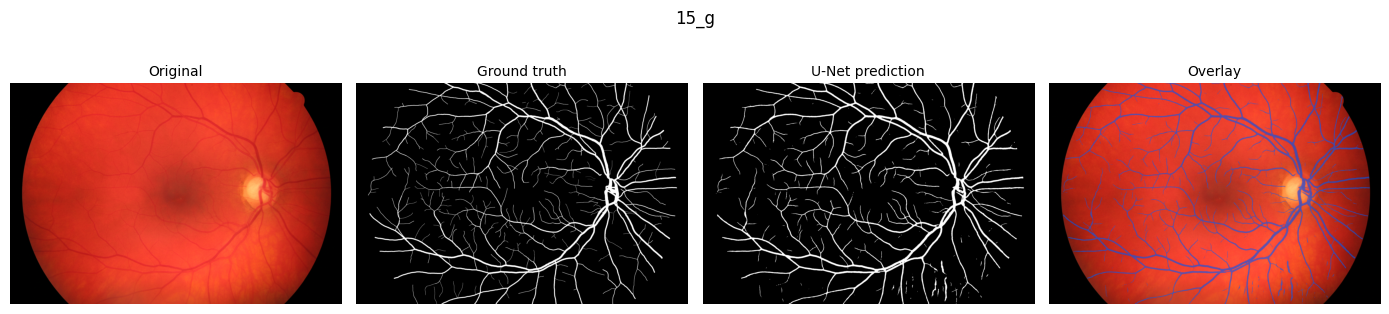

In [7]:
for image_id in TEST_IMAGES:
    img, gt, fv, pred = predictions[image_id]
    fig = visualize.compare_grid([
        ('Original', img),
        ('Ground truth', gt * 255),
        ('U-Net prediction', pred * 255),
        ('Overlay', visualize.overlay(img, pred, color=(0, 100, 255), alpha=0.6)),
    ], ncols=4, suptitle=image_id, figsize_per_panel=(3.5, 3.5))
    plt.show()

## 6. Zapis metryk

In [8]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
results_path = RESULTS_DIR / 'unet.json'
payload = {
    'method': 'unet_pytorch',
    'params': {
        'in_channels': 3, 'out_channels': 1, 'encoder': 'resnet34', 'encoder_weights': 'imagenet',
        'crop_size': CROP_SIZE,
        'crops_per_train_image': CROPS_PER_TRAIN_IMAGE,
        'crops_per_val_image':   CROPS_PER_VAL_IMAGE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'lr': LR,
        'loss': 'BCEWithLogits + Dice (both FOV-masked)',
        'augmentations': ['rot90', 'flip_h', 'flip_v'],
        'tile_size': 256, 'overlap': 32, 'threshold': 0.5,
        'n_inner_train_images': len(TRAIN_IMAGES_INNER),
        'n_inner_val_images':   len(VAL_IMAGES_INNER),
    },
    'test_images': list(TEST_IMAGES),
    'per_image': per_image,
    'aggregate': agg,
    'training_history': {
        'train_loss': history.train_loss,
        'val_loss':   history.val_loss,
        'val_gmean':  history.val_gmean,
    },
}
results_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False))
print(f'Metryki: {results_path}')
print(f'Model:   {model_path}  ({model_path.stat().st_size/1e6:.1f} MB)')

Metryki: /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/results/unet.json
Model:   /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/models/unet.pt  (97.9 MB)
